# Notebook 13 — Rolling 6-Month P&L Backtest: Calendar Spread

Rolling 6-month train / 6-month test backtest using a calendar spread:
train on each 6-month window, trade the NEXT 6-month window, then slide
forward and repeat - covering the full 2021-01 to 2025-06 span in 8
consecutive windows.

WINDOW 1: train Jan-Jun 2021,  trade Jul-Dec 2021
WINDOW 2: train Jul-Dec 2021,  trade Jan-Jun 2022
WINDOW 3: train Jan-Jun 2022,  trade Jul-Dec 2022
WINDOW 4: train Jul-Dec 2022,  trade Jan-Jun 2023
WINDOW 5: train Jan-Jun 2023,  trade Jul-Dec 2023
WINDOW 6: train Jul-Dec 2023,  trade Jan-Jun 2024
WINDOW 7: train Jan-Jun 2024,  trade Jul-Dec 2024
WINDOW 8: train Jul-Dec 2024,  trade Jan-Jun 2025

The model is RETRAINED every 6 months using ONLY the immediately
preceding 6 months - testing whether a short, recent, adaptive training
window keeps up with changing market conditions better than a fixed fit.

STRATEGIES:
  1. MANUAL AGREE RULE    - fixed rule, no training - included as a stable
                             baseline that is identical in every window.
  2. MANUAL DISAGREE RULE - logistic regression, retrained fresh in every
                             6-month window on only that window's data.
  3. DATA-DRIVEN MODEL    - Gradient Boosting Classifier, retrained fresh
                             in every 6-month window on only that window's
                             data.

TRADE STRUCTURE: calendar spread - sell near-week ATM, buy ~30-day ATM,
same strike (one continuous Rs 100,000 portfolio per strategy). This
isolates a vega/term-structure view with near-zero net theta relative to
an outright straddle, and was the stronger of two structures tested during
development (a butterfly variant was also tried and removed - it is a
looser match to a pure IV-direction bet, behaving more like a range/pin
bet, and underperformed the calendar spread in testing).

DATA REQUIRED (place all in one folder, set FOLDER below):
  - OPTIDX_NIFTY_CE_*.csv, OPTIDX_NIFTY_PE_*.csv  (RAW files, WITH
    Open/High/Low/Close - NOT options_liquid.csv)
  - FUTIDX_NIFTY_*.csv
  - hist_india_vix_*.csv
  - daily_volatility_features.csv
  - vix_us_daily.csv

HONEST CAVEATS:
  - No transaction costs, brokerage, STT, or slippage are modeled - and
    multi-leg structures like these have MORE legs to pay costs on than a
    single option or future.
  - Each 6-month training window is SHORT (roughly 25-45 flagged days,
    fewer still for the agree/disagree-only subsets) - a model retrained
    on this little data every window may be noisy from window to window
    even if there IS a real underlying signal. Look at the PATTERN across
    windows, not any single window in isolation.
  - The regime-gate and confirmation thresholds (75th/25th percentile) are
    still computed once from the FULL dataset, not per-window - a known,
    minor form of look-ahead in defining which days are eligible to trade.
  - IMPORTANT: check the "Sample balance check" output before trusting any
    P&L number - if LONG_CALENDAR vs SHORT_CALENDAR (or CE vs PE
    availability generally) is heavily lopsided, your options data may not
    have equal CE/PE coverage across all quarters, and results will be
    biased toward whichever side has better coverage.

In [1]:
import glob
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt

# ==========================================================================
# CONFIG - edit these
# ==========================================================================
FOLDER = r"C:\Users\ASUS\Desktop\volPredict"
STARTING_CAPITAL_PER_WINDOW = 100_000.0
LOTS_PER_TRADE = 1
LOT_SIZE_BY_YEAR = {2021: 75, 2022: 50, 2023: 50, 2024: 25, 2025: 25}

MIN_DTE_NEAR = 1
FAR_DTE_TARGET = 30
BUTTERFLY_WING_POINTS = 100  # distance of each wing strike from ATM, in NIFTY points

OVERALL_START = pd.Timestamp("2021-01-01")
OVERALL_END = pd.Timestamp("2025-06-30")
WINDOW_MONTHS = 6

In [2]:
# ==========================================================================
# STEP 1 - REBUILD THE REGIME-GATED FEATURE PIPELINE (same as notebook 9)
# ==========================================================================
print("=== STEP 1: REBUILDING FEATURE PIPELINE ===")

# NOTE: S&P 500 was tested as a feature (both signed return and absolute
# move) and found to CONSISTENTLY WORSEN out-of-sample accuracy on this
# model (see project notes) - it has been removed from the pipeline here.
# US VIX proved the more stable cross-market signal across all years
# 2021-2025, so it is the only US market input retained.
us_vix = pd.read_csv(os.path.join(FOLDER, "vix_us_daily.csv"))
us_vix["Date"] = pd.to_datetime(us_vix["DATE"])
us_vix = us_vix[["Date", "CLOSE"]].rename(columns={"CLOSE": "US_VIX_Close"})
us_vix = us_vix.dropna().sort_values("Date").reset_index(drop=True)

us_market = us_vix.sort_values("Date").reset_index(drop=True)
us_market["US_VIX_chg1d"] = us_market["US_VIX_Close"].diff(1)

iv_feat = pd.read_csv(os.path.join(FOLDER, "daily_volatility_features.csv"), parse_dates=["Date"])
iv_feat = iv_feat.sort_values("Date").reset_index(drop=True)

df = pd.merge_asof(iv_feat, us_market, on="Date", direction="backward", allow_exact_matches=False)
df = df.rename(columns={
    "US_VIX_Close": "US_VIX_prev_close", "US_VIX_chg1d": "US_VIX_prev_chg1d",
})
df["ATM_IV_30D_prev"] = df["ATM_IV_30D"].shift(1)
df["NIFTY_IV_chg1d"] = df["ATM_IV_30D"] - df["ATM_IV_30D_prev"]
df["SKEW_30D_prev"] = df["SKEW_30D"].shift(1)
df["SKEW_14D_prev"] = df["SKEW_14D"].shift(1)

fut_files = sorted(glob.glob(os.path.join(FOLDER, "FUTIDX_NIFTY_*.csv")))
fut_list = []
for f in fut_files:
    d = pd.read_csv(f)
    d.columns = d.columns.str.strip()
    fut_list.append(d)
fut = pd.concat(fut_list, ignore_index=True)
fut["Date"] = pd.to_datetime(fut["Date"].str.strip(), format="%d-%b-%Y")
fut["Underlying Value"] = pd.to_numeric(fut["Underlying Value"].astype(str).str.strip(), errors="coerce")
nifty_spot = fut.dropna(subset=["Underlying Value"]).groupby("Date")["Underlying Value"].first().reset_index()
nifty_spot = nifty_spot.rename(columns={"Underlying Value": "NIFTY_Spot"}).sort_values("Date").reset_index(drop=True)
nifty_spot["NIFTY_prev_return"] = np.log(nifty_spot["NIFTY_Spot"] / nifty_spot["NIFTY_Spot"].shift(1))
df = pd.merge(df, nifty_spot[["Date", "NIFTY_prev_return"]], on="Date", how="left")

india_vix_files = sorted(glob.glob(os.path.join(FOLDER, "hist_india_vix_*.csv")))
india_vix_list = []
for f in india_vix_files:
    d = pd.read_csv(f)
    d.columns = d.columns.str.strip()
    india_vix_list.append(d)
india_vix = pd.concat(india_vix_list, ignore_index=True)
india_vix["Date"] = pd.to_datetime(india_vix["Date"], dayfirst=True, errors="coerce")
india_vix = india_vix.rename(columns={"Close": "India_VIX_Close"})
india_vix = india_vix[["Date", "India_VIX_Close"]].dropna().sort_values("Date").reset_index(drop=True)
india_vix["India_VIX_Close"] = pd.to_numeric(india_vix["India_VIX_Close"], errors="coerce")
india_vix["India_VIX_prev_close"] = india_vix["India_VIX_Close"].shift(1)
india_vix["India_VIX_prev_chg1d"] = india_vix["India_VIX_prev_close"] - india_vix["India_VIX_Close"].shift(2)
df = pd.merge(df, india_vix[["Date", "India_VIX_prev_close", "India_VIX_prev_chg1d"]], on="Date", how="left")

LARGE_MOVE_THRESHOLD = df["US_VIX_prev_chg1d"].abs().quantile(0.75)
df["Large_US_Move_Flag"] = (df["US_VIX_prev_chg1d"].abs() >= LARGE_MOVE_THRESHOLD).astype("Int64")
df["NIFTY_IV_Up_Label"] = (df["NIFTY_IV_chg1d"] > 0).astype("Int64")

flagged_df = df[df["Large_US_Move_Flag"] == 1].copy()
flagged_df = flagged_df.dropna(subset=["NIFTY_IV_Up_Label", "NIFTY_prev_return", "US_VIX_prev_chg1d"])

NIFTY_MEANINGFUL_MOVE_THRESHOLD = flagged_df["NIFTY_prev_return"].abs().quantile(0.25)
flagged_df["us_says_up_vol"] = flagged_df["US_VIX_prev_chg1d"] > 0
flagged_df["nifty_move_meaningful"] = flagged_df["NIFTY_prev_return"].abs() >= NIFTY_MEANINGFUL_MOVE_THRESHOLD
flagged_df["nifty_already_fell"] = flagged_df["NIFTY_prev_return"] < 0
flagged_df["signal_category"] = "neutral"
flagged_df.loc[
    flagged_df["nifty_move_meaningful"] & (flagged_df["us_says_up_vol"] == flagged_df["nifty_already_fell"]),
    "signal_category"
] = "agree"
flagged_df.loc[
    flagged_df["nifty_move_meaningful"] & (flagged_df["us_says_up_vol"] != flagged_df["nifty_already_fell"]),
    "signal_category"
] = "disagree"
flagged_df["rule_pred"] = flagged_df["us_says_up_vol"].astype(int)

print(f"Flagged (regime-gated) days: {len(flagged_df)} ({len(flagged_df)/len(df)*100:.1f}% of all trading days)")

DIS_FEATS = ["NIFTY_prev_return", "US_VIX_prev_close", "US_VIX_prev_chg1d", "SKEW_14D_prev", "SKEW_30D_prev"]
DD_FEATS = ["US_VIX_prev_chg1d", "US_VIX_prev_close", "NIFTY_prev_return",
            "SKEW_30D_prev", "SKEW_14D_prev", "India_VIX_prev_chg1d"]

agree_days = flagged_df[flagged_df["signal_category"] == "agree"].sort_values("Date").reset_index(drop=True)
disagree_days = flagged_df[flagged_df["signal_category"] == "disagree"].dropna(subset=DIS_FEATS + ["NIFTY_IV_Up_Label"]).sort_values("Date").reset_index(drop=True)

dd_all = flagged_df.dropna(subset=DD_FEATS + ["NIFTY_IV_Up_Label"]).sort_values("Date").reset_index(drop=True)
dd_all["abs_us_vix_chg"] = dd_all["US_VIX_prev_chg1d"].abs()
dd_all["abs_nifty_move"] = dd_all["NIFTY_prev_return"].abs()
dd_all["sign_agree"] = np.sign(dd_all["US_VIX_prev_chg1d"]) * np.sign(-dd_all["NIFTY_prev_return"])
dd_all["product_raw"] = dd_all["US_VIX_prev_chg1d"] * (-dd_all["NIFTY_prev_return"])
dd_all["min_magnitude"] = np.minimum(
    dd_all["abs_us_vix_chg"] / dd_all["abs_us_vix_chg"].std(),
    dd_all["abs_nifty_move"] / dd_all["abs_nifty_move"].std(),
)
DD_ALL_FEATS = DD_FEATS + ["abs_us_vix_chg", "abs_nifty_move", "sign_agree", "product_raw", "min_magnitude"]

=== STEP 1: REBUILDING FEATURE PIPELINE ===
Flagged (regime-gated) days: 163 (24.8% of all trading days)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31256\4134646280.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  india_vix["Date"] = pd.to_datetime(india_vix["Date"], dayfirst=True, errors="coerce")


In [3]:
# ==========================================================================
# STEP 2 - BUILD THE ROLLING 6-MONTH TRAIN/TEST WINDOWS
# ==========================================================================
print(f"\n=== STEP 2: BUILDING ROLLING {WINDOW_MONTHS}-MONTH WINDOWS ===")

windows = []
cur = OVERALL_START
while True:
    train_start = cur
    train_end = cur + pd.DateOffset(months=WINDOW_MONTHS) - pd.Timedelta(days=1)
    test_start = train_end + pd.Timedelta(days=1)
    test_end = test_start + pd.DateOffset(months=WINDOW_MONTHS) - pd.Timedelta(days=1)
    if test_start >= OVERALL_END:
        break
    windows.append((train_start, train_end, test_start, min(test_end, OVERALL_END)))
    cur = cur + pd.DateOffset(months=WINDOW_MONTHS)

print(f"Built {len(windows)} rolling windows:")
for i, (tr_s, tr_e, te_s, te_e) in enumerate(windows, 1):
    print(f"  Window {i}: train [{tr_s.date()} to {tr_e.date()}]  ->  test [{te_s.date()} to {te_e.date()}]")

all_signals_list = []
for window_num, (train_start, train_end, test_start, test_end) in enumerate(windows, 1):
    # --- manual agree: no training, applies unchanged in every window ---
    win_agree = agree_days[(agree_days["Date"] >= test_start) & (agree_days["Date"] <= test_end)]
    if len(win_agree) > 0:
        sig = win_agree[["Date", "rule_pred", "NIFTY_IV_Up_Label"]].rename(columns={"rule_pred": "prediction"}).copy()
        sig["strategy"] = "manual_agree"
        sig["window"] = window_num
        all_signals_list.append(sig)

    # --- manual disagree: retrain fresh on THIS window's train period only ---
    dis_train = disagree_days[(disagree_days["Date"] >= train_start) & (disagree_days["Date"] <= train_end)]
    dis_test = disagree_days[(disagree_days["Date"] >= test_start) & (disagree_days["Date"] <= test_end)]
    if len(dis_train) >= 8 and len(set(dis_train["NIFTY_IV_Up_Label"])) >= 2 and len(dis_test) > 0:
        model = LogisticRegression(max_iter=1000, class_weight="balanced")
        model.fit(dis_train[DIS_FEATS], dis_train["NIFTY_IV_Up_Label"])
        preds = model.predict(dis_test[DIS_FEATS])
        sig = dis_test[["Date", "NIFTY_IV_Up_Label"]].copy()
        sig["prediction"] = preds
        sig["strategy"] = "manual_disagree"
        sig["window"] = window_num
        all_signals_list.append(sig)

    # --- data-driven: retrain fresh on THIS window's train period only ---
    dd_train = dd_all[(dd_all["Date"] >= train_start) & (dd_all["Date"] <= train_end)]
    dd_test = dd_all[(dd_all["Date"] >= test_start) & (dd_all["Date"] <= test_end)]
    if len(dd_train) >= 8 and len(set(dd_train["NIFTY_IV_Up_Label"])) >= 2 and len(dd_test) > 0:
        model = GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=0.05, min_samples_leaf=5, random_state=42)
        model.fit(dd_train[DD_ALL_FEATS], dd_train["NIFTY_IV_Up_Label"])
        preds = model.predict(dd_test[DD_ALL_FEATS])
        sig = dd_test[["Date", "NIFTY_IV_Up_Label"]].copy()
        sig["prediction"] = preds
        sig["strategy"] = "data_driven"
        sig["window"] = window_num
        all_signals_list.append(sig)

all_signals = pd.concat(all_signals_list, ignore_index=True) if all_signals_list else pd.DataFrame()
all_signals["prediction"] = all_signals["prediction"].astype(int)
all_signals["NIFTY_IV_Up_Label"] = all_signals["NIFTY_IV_Up_Label"].astype(int)
print(f"\nTotal signals generated across all windows: {len(all_signals)}")
print(all_signals.groupby(["strategy"]).size())


=== STEP 2: BUILDING ROLLING 6-MONTH WINDOWS ===
Built 8 rolling windows:
  Window 1: train [2021-01-01 to 2021-06-30]  ->  test [2021-07-01 to 2021-12-31]
  Window 2: train [2021-07-01 to 2021-12-31]  ->  test [2022-01-01 to 2022-06-30]
  Window 3: train [2022-01-01 to 2022-06-30]  ->  test [2022-07-01 to 2022-12-31]
  Window 4: train [2022-07-01 to 2022-12-31]  ->  test [2023-01-01 to 2023-06-30]
  Window 5: train [2023-01-01 to 2023-06-30]  ->  test [2023-07-01 to 2023-12-31]
  Window 6: train [2023-07-01 to 2023-12-31]  ->  test [2024-01-01 to 2024-06-30]
  Window 7: train [2024-01-01 to 2024-06-30]  ->  test [2024-07-01 to 2024-12-31]
  Window 8: train [2024-07-01 to 2024-12-31]  ->  test [2025-01-01 to 2025-06-30]

Total signals generated across all windows: 222
strategy
data_driven     150
manual_agree     72
dtype: int64


In [4]:
# ==========================================================================
# STEP 3 - LOAD RAW OPTIONS DATA
# ==========================================================================
print("\n=== STEP 3: LOADING RAW OPTIONS DATA ===")

def load_raw_options(pattern, opt_type_label):
    files = sorted(glob.glob(os.path.join(FOLDER, pattern)))
    if not files:
        raise FileNotFoundError(f"No files found for pattern '{pattern}' in {FOLDER}.")
    dfs = []
    for f in files:
        d = pd.read_csv(f)
        d.columns = d.columns.str.strip()
        dfs.append(d)
    out = pd.concat(dfs, ignore_index=True)
    out["Date"] = pd.to_datetime(out["Date"].str.strip(), format="%d-%b-%Y")
    out["Expiry"] = pd.to_datetime(out["Expiry"].str.strip(), format="%d-%b-%Y")
    for col in ["Strike Price", "Open", "High", "Low", "Close", "Underlying Value"]:
        out[col] = pd.to_numeric(out[col].astype(str).str.strip(), errors="coerce")
    print(f"  Loaded {opt_type_label}: {len(files)} files, {len(out):,} rows")
    return out

calls = load_raw_options("OPTIDX_NIFTY_CE_*.csv", "Calls (CE)")
puts = load_raw_options("OPTIDX_NIFTY_PE_*.csv", "Puts (PE)")


=== STEP 3: LOADING RAW OPTIONS DATA ===


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31256\1513398701.py:12: DtypeWarning: Columns (8,10) have mixed types. Specify dtype option on import or set low_memory=False.
  d = pd.read_csv(f)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_31256\1513398701.py:12: DtypeWarning: Columns (8,10) have mixed types. Specify dtype option on import or set low_memory=False.
  d = pd.read_csv(f)


  Loaded Calls (CE): 18 files, 1,040,344 rows


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31256\1513398701.py:12: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  d = pd.read_csv(f)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_31256\1513398701.py:12: DtypeWarning: Columns (8,10) have mixed types. Specify dtype option on import or set low_memory=False.
  d = pd.read_csv(f)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_31256\1513398701.py:12: DtypeWarning: Columns (8,10) have mixed types. Specify dtype option on import or set low_memory=False.
  d = pd.read_csv(f)


  Loaded Puts (PE): 18 files, 1,075,736 rows


In [5]:
# ==========================================================================
# STEP 4 - CALENDAR SPREAD SIMULATION
# ==========================================================================
print("\n=== STEP 4: SIMULATING CALENDAR SPREADS ===")

def get_calendar_legs(options_df, trade_date):
    day = options_df[options_df["Date"] == trade_date].copy()
    if day.empty:
        return None
    day = day.dropna(subset=["Underlying Value", "Strike Price"])
    if day.empty:
        return None
    day["dte"] = (day["Expiry"] - trade_date).dt.days
    underlying = day["Underlying Value"].iloc[0]

    near_candidates = day[day["dte"] >= MIN_DTE_NEAR]
    if near_candidates.empty:
        return None
    near_expiry = near_candidates["dte"].min()
    near_expiry_date = near_candidates[near_candidates["dte"] == near_expiry]["Expiry"].iloc[0]

    far_expiry_date = day.iloc[(day["dte"] - FAR_DTE_TARGET).abs().argsort()].iloc[0]["Expiry"]
    if far_expiry_date == near_expiry_date:
        return None

    near_chain = day[day["Expiry"] == near_expiry_date].copy()
    near_chain["dist"] = (near_chain["Strike Price"] - underlying).abs()
    atm_strike = near_chain.sort_values("dist").iloc[0]["Strike Price"]

    near_row = near_chain[near_chain["Strike Price"] == atm_strike]
    far_chain = day[(day["Expiry"] == far_expiry_date) & (day["Strike Price"] == atm_strike)]
    if near_row.empty or far_chain.empty:
        return None
    near_row, far_row = near_row.iloc[0], far_chain.iloc[0]

    if pd.isna(near_row["Open"]) or pd.isna(near_row["Close"]) or pd.isna(far_row["Open"]) or pd.isna(far_row["Close"]):
        return None

    return {
        "strike": atm_strike,
        "near_open": near_row["Open"], "near_close": near_row["Close"],
        "far_open": far_row["Open"], "far_close": far_row["Close"],
    }


trade_log = []
for _, row in all_signals.iterrows():
    trade_date, year = row["Date"], row["Date"].year
    lot_size = LOT_SIZE_BY_YEAR.get(year, 50)
    option_side = calls if row["prediction"] == 1 else puts

    legs = get_calendar_legs(option_side, trade_date)
    if legs is None:
        continue

    direction = 1 if row["prediction"] == 1 else -1
    near_pnl = -(legs["near_close"] - legs["near_open"]) * direction
    far_pnl = (legs["far_close"] - legs["far_open"]) * direction
    pnl_per_lot = (near_pnl + far_pnl) * lot_size   # P&L for exactly ONE lot - scaling by capital happens next, in Step 5

    trade_log.append({
        "Date": trade_date, "window": row["window"], "strategy": row["strategy"], "structure": "calendar",
        "position": "LONG_CALENDAR" if direction == 1 else "SHORT_CALENDAR",
        "pnl_per_lot": pnl_per_lot,
        "iv_direction_correct": int(row["prediction"]) == int(row["NIFTY_IV_Up_Label"]),
    })

trades = pd.DataFrame(trade_log).sort_values(["strategy", "Date"]).reset_index(drop=True)
print(f"Total simulated calendar trades: {len(trades)}")

if trades.empty:
    raise RuntimeError("No trades were simulated - check that your options files cover the full period.")

print("\n--- Sample balance check, calendar (verify this isn't lopsided before trusting P&L) ---")
print(trades["position"].value_counts())


=== STEP 4: SIMULATING CALENDAR SPREADS ===
Total simulated calendar trades: 164

--- Sample balance check, calendar (verify this isn't lopsided before trusting P&L) ---
position
LONG_CALENDAR     99
SHORT_CALENDAR    65
Name: count, dtype: int64


In [6]:
# ==========================================================================
# STEP 5 - COMPOUNDING EQUITY CURVE (single continuous portfolio per strategy)
# ==========================================================================
# Each strategy starts with EXACTLY Rs 100,000 ONCE, at the very first
# trade of the whole backtest - NOT reset every window. From then on,
# position size for each new trade is scaled to CURRENT capital at that
# point (roughly 10% of current capital risked per trade, converted to a
# whole number of lots), so a strategy that has grown its capital trades
# bigger, and one that has shrunk trades smaller - a realistic compounding
# portfolio, not a fixed bet size throughout.
#
# Position sizing here is a simplified proxy (10% of capital / per-lot P&L
# magnitude, rounded down to a whole lot, minimum 1) - NOT a precise broker
# margin calculation. Real margin for a calendar spread is typically much
# less than the full premium due to margin offsetting between the two legs.

print("\n=== STEP 5: BUILDING COMPOUNDING EQUITY CURVES ===")

window_labels = {i: f"W{i}: {w[2].strftime('%Y-%m')} to {w[3].strftime('%Y-%m')}" for i, w in enumerate(windows, 1)}

equity_curves = {}
compounded_trade_log = []

for (structure, strat), grp in trades.groupby(["structure", "strategy"]):
    strat_trades = grp.sort_values("Date").reset_index(drop=True)
    capital = STARTING_CAPITAL_PER_WINDOW   # exactly Rs 100,000, ONCE, at the start of this structure+strategy's history

    curve_rows = [{"Date": strat_trades["Date"].min() - pd.Timedelta(days=1), "Capital": capital}]

    for _, t in strat_trades.iterrows():
        capital_at_risk = capital * 0.10
        # Cap lot count to something realistically tradeable in one day
        # (NIFTY options rarely have enough same-day liquidity for tens of
        # thousands of lots) - without this cap, a few early lucky trades
        # can compound into unrealistic position sizes on a small sample.
        MAX_LOTS_PER_TRADE = 50
        implied_lots = max(1, min(MAX_LOTS_PER_TRADE, int(capital_at_risk / max(abs(t["pnl_per_lot"]), 1.0))))
        trade_pnl = t["pnl_per_lot"] * implied_lots

        capital += trade_pnl
        compounded_trade_log.append({
            "Date": t["Date"], "window": t["window"], "strategy": strat, "structure": structure,
            "position": t["position"], "lots": implied_lots,
            "pnl": trade_pnl, "capital_after": capital,
            "iv_direction_correct": t["iv_direction_correct"],
        })
        curve_rows.append({"Date": t["Date"], "Capital": capital})

    equity_curves[(structure, strat)] = pd.DataFrame(curve_rows)

compounded_trades = pd.DataFrame(compounded_trade_log).sort_values(["structure", "strategy", "Date"]).reset_index(drop=True)

print("Starting capital per (structure, strategy): Rs 100,000 (once, at the first trade - never reset)")
print()
for (structure, strat), curve in equity_curves.items():
    start_cap = curve["Capital"].iloc[0]
    end_cap = curve["Capital"].iloc[-1]
    print(f"  {structure:10s} / {strat}: Rs {start_cap:,.0f} -> Rs {end_cap:,.0f}  "
          f"({(end_cap/start_cap - 1)*100:+.1f}% total return, compounded)")


=== STEP 5: BUILDING COMPOUNDING EQUITY CURVES ===
Starting capital per (structure, strategy): Rs 100,000 (once, at the first trade - never reset)

  calendar   / data_driven: Rs 100,000 -> Rs 755,490  (+655.5% total return, compounded)
  calendar   / manual_agree: Rs 100,000 -> Rs 102,801  (+2.8% total return, compounded)


In [7]:
# ==========================================================================
# STEP 5b - P&L PER WINDOW, PER STRUCTURE, PER STRATEGY (compounded trade sizes)
# ==========================================================================
print("\n=== STEP 5b: P&L PER ROLLING WINDOW, PER STRUCTURE, PER STRATEGY ===")

rolling_rows = []
for (structure, strat, window_num), grp in compounded_trades.groupby(["structure", "strategy", "window"]):
    total_pnl = grp["pnl"].sum()
    rolling_rows.append({
        "structure": structure, "strategy": strat, "window": window_num, "test_period": window_labels[window_num],
        "n_trades": len(grp), "win_rate": (grp["pnl"] > 0).mean(),
        "iv_direction_accuracy": grp["iv_direction_correct"].mean(),
        "total_pnl": total_pnl,
    })

rolling_summary = pd.DataFrame(rolling_rows).sort_values(["structure", "strategy", "window"])
print(rolling_summary.to_string(index=False))
rolling_summary.to_csv(os.path.join(FOLDER, "rolling_pnl_summary.csv"), index=False)
compounded_trades.to_csv(os.path.join(FOLDER, "rolling_pnl_trade_log.csv"), index=False)
print(f"\nSaved: {os.path.join(FOLDER, 'rolling_pnl_summary.csv')}")
print(f"Saved: {os.path.join(FOLDER, 'rolling_pnl_trade_log.csv')}")

print("\n--- Cumulative P&L per (structure, strategy) (sum across all windows) ---")
print(rolling_summary.groupby(["structure", "strategy"])["total_pnl"].sum())


=== STEP 5b: P&L PER ROLLING WINDOW, PER STRUCTURE, PER STRATEGY ===
structure     strategy  window            test_period  n_trades  win_rate  iv_direction_accuracy  total_pnl
 calendar  data_driven       1 W1: 2021-07 to 2021-12         5  0.400000               0.800000   -6708.75
 calendar  data_driven       2 W2: 2022-01 to 2022-06         9  0.555556               0.777778    3135.00
 calendar  data_driven       3 W3: 2022-07 to 2022-12        10  0.800000               0.700000   51632.50
 calendar  data_driven       4 W4: 2023-01 to 2023-06        10  0.600000               0.700000   30805.00
 calendar  data_driven       5 W5: 2023-07 to 2023-12        12  0.833333               0.666667  177100.00
 calendar  data_driven       6 W6: 2024-01 to 2024-06         5  0.800000               0.400000  129287.50
 calendar  data_driven       7 W7: 2024-07 to 2024-12        24  0.791667               0.541667  466471.25
 calendar  data_driven       8 W8: 2025-01 to 2025-06        37  0


=== STEP 6: PLOTTING PER-WINDOW P&L AND CUMULATIVE EQUITY ===


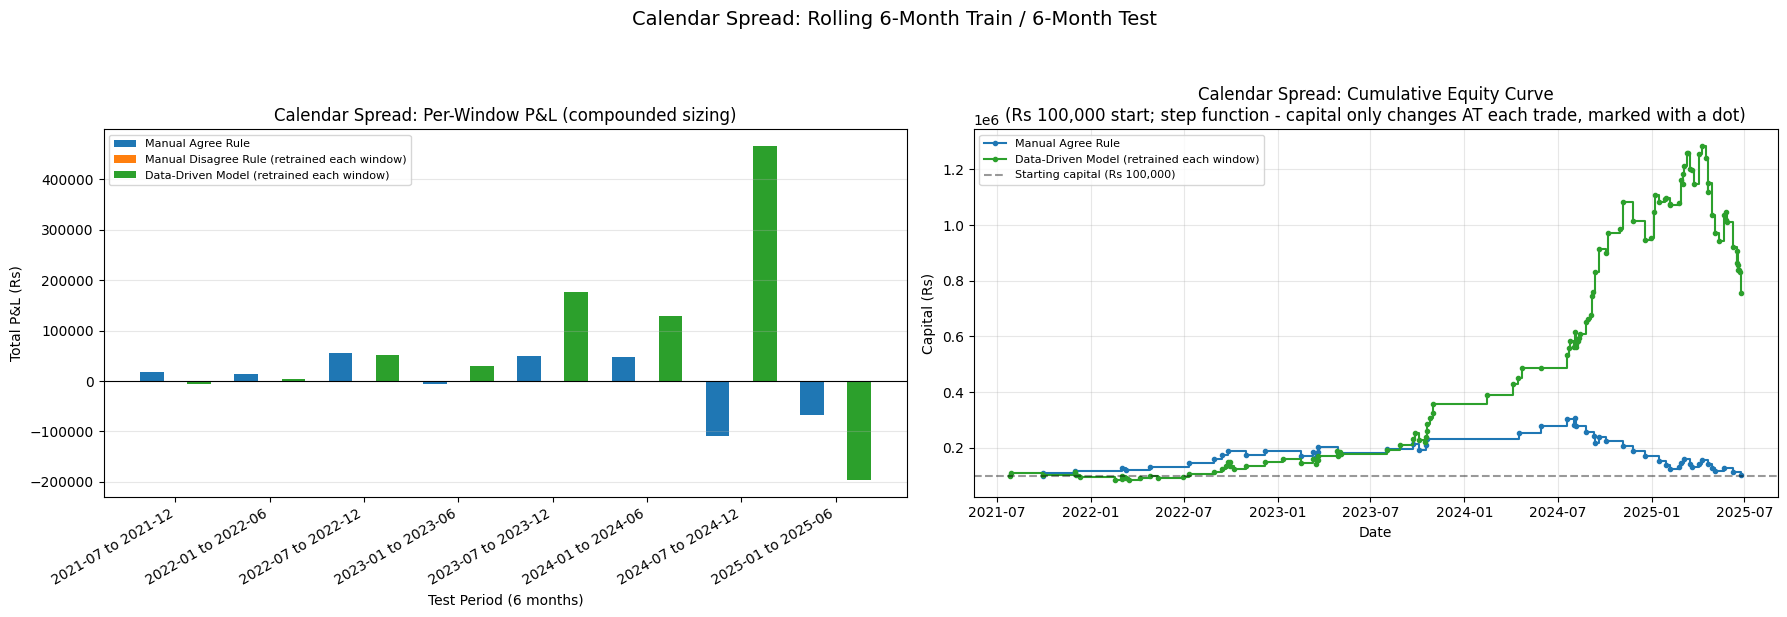

Saved: C:\Users\ASUS\Desktop\volPredict\rolling_pnl_chart.png

=== DONE ===
Compare retraining consistency window-to-window: if P&L is choppy or
decays badly in later windows (especially 2024-2025), that reflects
the real regime shift found elsewhere in this project (US-India
correlation breakdown in 2025), not a flaw specific to this backtest.


In [8]:
# ==========================================================================
# STEP 6 - PLOT: PER-WINDOW P&L AND CUMULATIVE EQUITY CURVE
# ==========================================================================
print("\n=== STEP 6: PLOTTING PER-WINDOW P&L AND CUMULATIVE EQUITY ===")

strategies = ["manual_agree", "manual_disagree", "data_driven"]
colors = {"manual_agree": "tab:blue", "manual_disagree": "tab:orange", "data_driven": "tab:green"}
labels = {"manual_agree": "Manual Agree Rule", "manual_disagree": "Manual Disagree Rule (retrained each window)", "data_driven": "Data-Driven Model (retrained each window)"}

fig, (ax_bar, ax_curve) = plt.subplots(1, 2, figsize=(18, 6))

calendar_summary = rolling_summary[rolling_summary["structure"] == "calendar"]

# --- Left: per-window P&L ---
window_nums = sorted(calendar_summary["window"].unique())
x = np.arange(len(window_nums))
width = 0.25
for i, strat in enumerate(strategies):
    vals = [calendar_summary[(calendar_summary["strategy"] == strat) & (calendar_summary["window"] == w)]["total_pnl"].sum() for w in window_nums]
    ax_bar.bar(x + (i - 1) * width, vals, width, label=labels[strat], color=colors[strat])
ax_bar.axhline(0, color="black", linewidth=0.8)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([window_labels[w].split(": ")[1] for w in window_nums], rotation=30, ha="right")
ax_bar.set_xlabel("Test Period (6 months)")
ax_bar.set_ylabel("Total P&L (Rs)")
ax_bar.set_title("Calendar Spread: Per-Window P&L (compounded sizing)")
ax_bar.legend(fontsize=8)
ax_bar.grid(alpha=0.3, axis="y")

# --- Right: cumulative equity curve, drawn as a STEP FUNCTION with a marker
# at every trade. Capital is only actually updated at trade dates - it does
# NOT move continuously between them - so a step function (flat between
# trades, vertical jump exactly at each trade) is the honest way to draw
# this, not a sloped line implying gradual, continuous change.
for strat in strategies:
    if ("calendar", strat) in equity_curves:
        curve = equity_curves[("calendar", strat)]
        ax_curve.plot(curve["Date"], curve["Capital"], label=labels[strat], color=colors[strat],
                      linewidth=1.5, drawstyle="steps-post",
                      marker="o", markersize=3, markevery=1)
ax_curve.axhline(STARTING_CAPITAL_PER_WINDOW, color="black", linestyle="--", alpha=0.4,
                  label=f"Starting capital (Rs {STARTING_CAPITAL_PER_WINDOW:,.0f})")
ax_curve.set_xlabel("Date")
ax_curve.set_ylabel("Capital (Rs)")
ax_curve.set_title("Calendar Spread: Cumulative Equity Curve\n(Rs 100,000 start; step function - capital only changes AT each trade, marked with a dot)")
ax_curve.legend(fontsize=8)
ax_curve.grid(alpha=0.3)

plt.suptitle("Calendar Spread: Rolling 6-Month Train / 6-Month Test", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FOLDER, "rolling_pnl_chart.png"), dpi=100)
plt.show()
print(f"Saved: {os.path.join(FOLDER, 'rolling_pnl_chart.png')}")

print("\n=== DONE ===")
print("Compare retraining consistency window-to-window: if P&L is choppy or")
print("decays badly in later windows (especially 2024-2025), that reflects")
print("the real regime shift found elsewhere in this project (US-India")
print("correlation breakdown in 2025), not a flaw specific to this backtest.")